# **1. Perkenalan Dataset**
Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:
1. **Sumber Dataset**:
   Dataset dapat diperoleh dari berbagai sumber, seperti *Kaggle*, *UCI ML Repository*, *Open Data* atau data primer yang dikumpulkan sendiri.
   *Pada proyek ini digunakan Pima Indians Diabetes Database dari Kaggle.*

# **2. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**
Memuat dataset ke dalam notebook dan menampilkan strukturnya.

In [2]:
# Memuat dataset dari direktori atas
df = pd.read_csv('../diabetes_dataset_raw.csv')
display(df.head())
display(df.info())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

# **4. Exploratory Data Analysis (EDA)**
Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset secara menyeluruh.

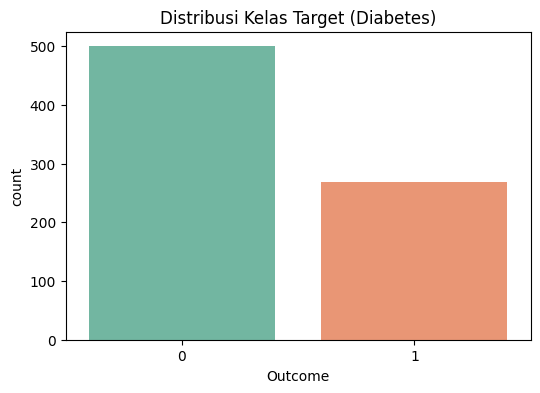

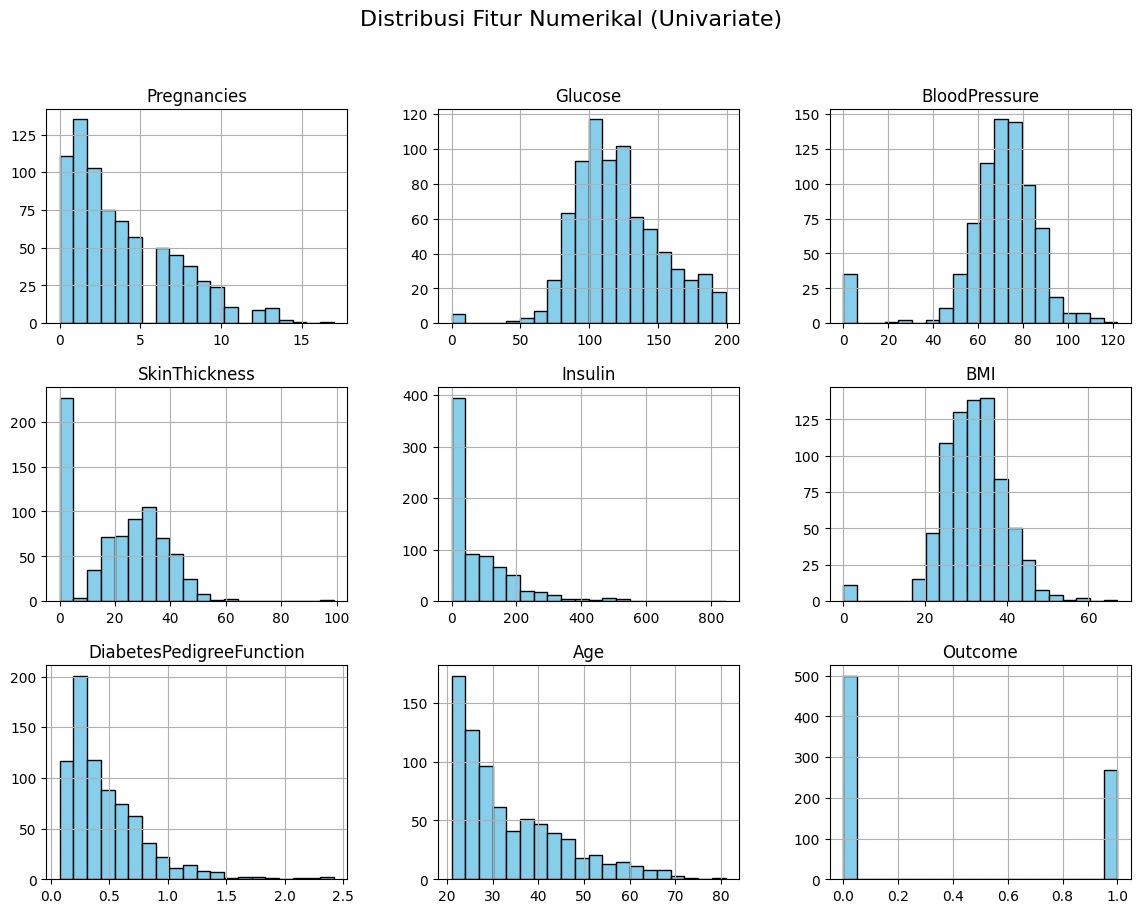

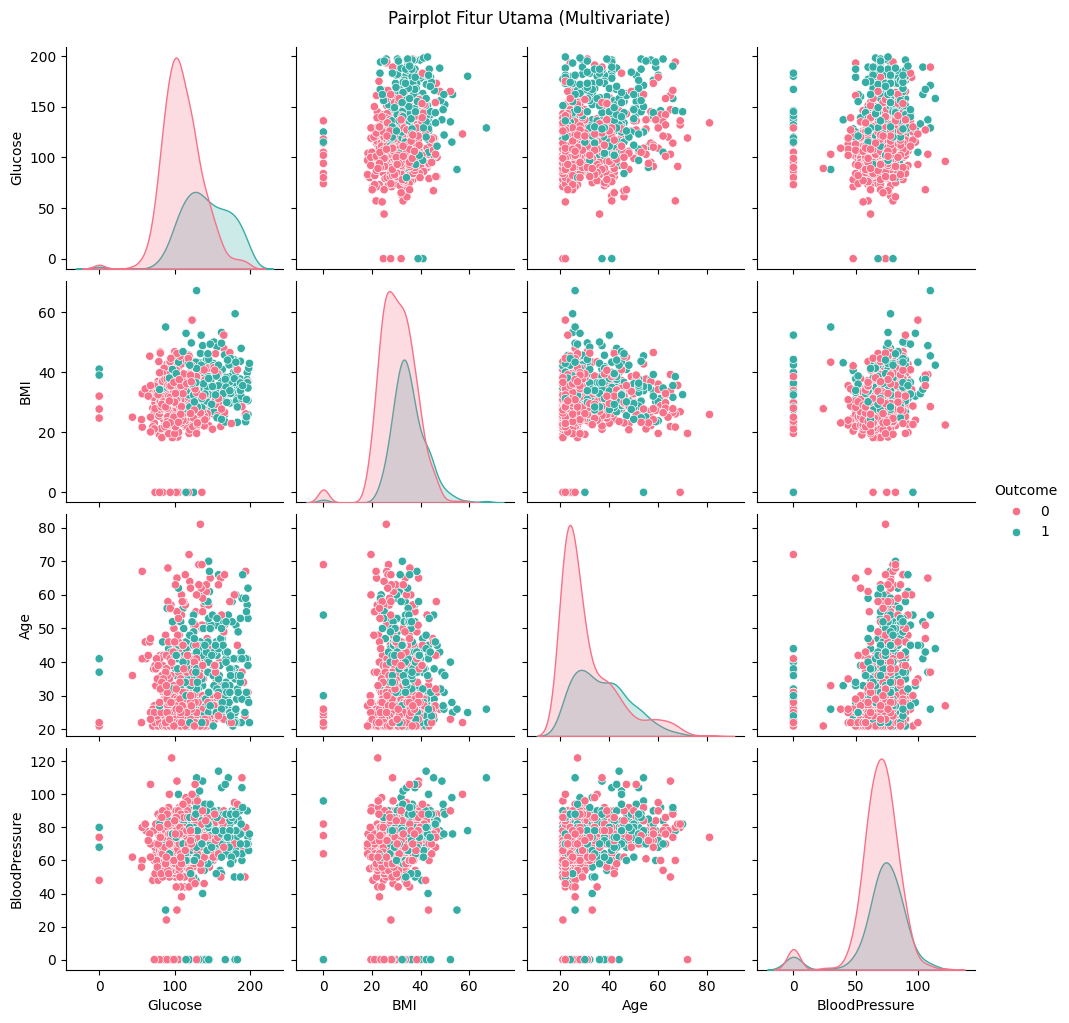

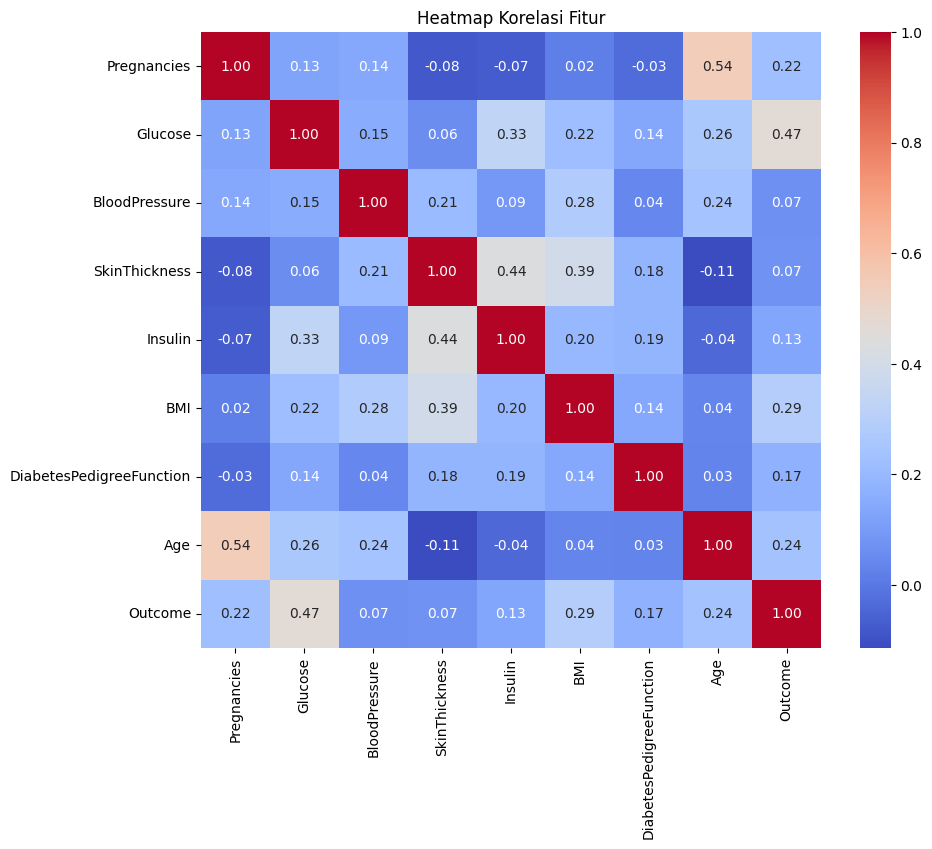

In [3]:
# 1. Menampilkan Distribusi Kelas Target (Kategorikal / Label)
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Distribusi Kelas Target (Diabetes)')
plt.show()

# 2. EDA Univariate (Distribusi Fitur Numerikal)
df.hist(bins=20, figsize=(14, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerikal (Univariate)', fontsize=16)
plt.show()

# 3. EDA Multivariate (Pairplot untuk Fitur Utama)
sns.pairplot(df[['Glucose', 'BMI', 'Age', 'BloodPressure', 'Outcome']], hue='Outcome', palette='husl')
plt.suptitle('Pairplot Fitur Utama (Multivariate)', y=1.02)
plt.show()

# 4. Menampilkan Matriks Korelasi
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur')
plt.show()

# **5. Data Preprocessing**
Melakukan pembersihan data, menangani missing values, menghapus duplikat, dan feature scaling.

In [4]:
# 1. Mengecek missing values
print("Jumlah missing values:")
print(df.isnull().sum())

# 2. Menangani Data Duplikat
duplicate_count = df.duplicated().sum()
print(f"\nJumlah data duplikat sebelum dihapus: {duplicate_count}")
df = df.drop_duplicates()
print(f"Jumlah data duplikat setelah dihapus: {df.duplicated().sum()}")

# 3. Feature Scaling (Standardisasi)
scaler = StandardScaler()
features = df.drop('Outcome', axis=1).columns
df[features] = scaler.fit_transform(df[features])

print("\nData setelah dilakukan Feature Scaling:")
display(df.head())

# Menyimpan Data Bersih
df.to_csv('diabetes_preprocessing.csv', index=False)
print("\nDataset hasil preprocessing berhasil disimpan sebagai 'diabetes_preprocessing.csv'.")

Jumlah missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Jumlah data duplikat sebelum dihapus: 0
Jumlah data duplikat setelah dihapus: 0

Data setelah dilakukan Feature Scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995,1
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672,0
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584,1
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549,0
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496,1



Dataset hasil preprocessing berhasil disimpan sebagai 'diabetes_preprocessing.csv'.
